In [3]:
# Import Libraries & Load Dataset

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import (
    classification_report, accuracy_score,
    roc_auc_score, roc_curve, confusion_matrix, ConfusionMatrixDisplay
)
from sklearn.utils import resample
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('online_retail_II.csv', encoding='latin-1')

print('=== DATASET LOADED ===')
print(f'Total rows: {df.shape[0]:,}')
print(f'Total columns: {df.shape[1]}')
print(f'Columns: {list(df.columns)}')
print(f'Date range: {df["InvoiceDate"].min()} to {df["InvoiceDate"].max()}')
print(f'Unique customers: {df["Customer ID"].nunique():,}')
print(f'Unique countries: {df["Country"].nunique()}')
df.head()

=== DATASET LOADED ===
Total rows: 1,067,371
Total columns: 8
Columns: ['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'Price', 'Customer ID', 'Country']
Date range: 2009-12-01 07:45:00 to 2011-12-09 12:50:00
Unique customers: 5,942
Unique countries: 43


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [4]:
# Data Cleaning

print('=== BEFORE CLEANING ===')
print(f'Total rows: {df.shape[0]:,}')
print(f'Missing Customer IDs: {df["Customer ID"].isnull().sum():,}')
print(f'Cancelled invoices: {df["Invoice"].astype(str).str.startswith("C").sum():,}')
print(f'Negative quantities: {(df["Quantity"] < 0).sum():,}')
print(f'Negative/zero prices: {(df["Price"] <= 0).sum():,}')

df_clean = df.dropna(subset=['Customer ID'])
df_clean = df_clean[~df_clean['Invoice'].astype(str).str.startswith('C')]
df_clean = df_clean[df_clean['Quantity'] > 0]
df_clean = df_clean[df_clean['Price'] > 0]
df_clean['TotalPrice'] = df_clean['Quantity'] * df_clean['Price']
df_clean['InvoiceDate'] = pd.to_datetime(df_clean['InvoiceDate'])

print('\n=== AFTER CLEANING ===')
print(f'Total rows remaining: {df_clean.shape[0]:,}')
print(f'Rows removed: {df.shape[0] - df_clean.shape[0]:,}')
print(f'Unique customers remaining: {df_clean["Customer ID"].nunique():,}')
print('\nCleaning complete!')

=== BEFORE CLEANING ===
Total rows: 1,067,371
Missing Customer IDs: 243,007
Cancelled invoices: 19,494
Negative quantities: 22,950
Negative/zero prices: 6,207

=== AFTER CLEANING ===
Total rows remaining: 805,549
Rows removed: 261,822
Unique customers remaining: 5,878

Cleaning complete!


=== DESCRIPTIVE STATISTICS ===
        Quantity      Price  TotalPrice
count  805549.00  805549.00   805549.00
mean       13.29       3.21       22.03
std       143.63      29.20      224.04
min         1.00       0.00        0.00
25%         2.00       1.25        4.95
50%         5.00       1.95       11.85
75%        12.00       3.75       19.50
max     80995.00   10953.50   168469.60

=== TOP 10 COUNTRIES BY TRANSACTION COUNT ===
Country
United Kingdom    725250
Germany            16694
EIRE               15743
France             13812
Netherlands         5088
Spain               3719
Belgium             3068
Switzerland         3011
Portugal            2446
Australia           1812
Name: count, dtype: int64

=== TOP 10 COUNTRIES BY TOTAL REVENUE ===
Country
United Kingdom    14723147.52
EIRE                621631.11
Netherlands         554232.34
Germany             431262.46
France              355257.47
Australia           169968.11
Spain               109178.53
Switzerland      

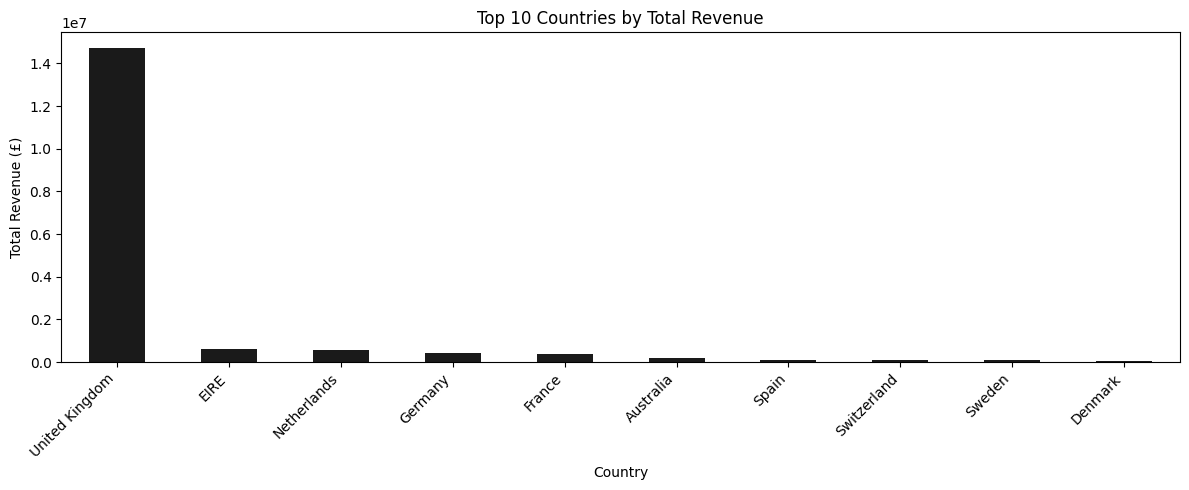

Saved: fig1_revenue_by_country.png


In [5]:
# Descriptive Statistics + Revenue by Country

print('=== DESCRIPTIVE STATISTICS ===')
print(df_clean[['Quantity', 'Price', 'TotalPrice']].describe().round(2))

print('\n=== TOP 10 COUNTRIES BY TRANSACTION COUNT ===')
print(df_clean['Country'].value_counts().head(10))

print('\n=== TOP 10 COUNTRIES BY TOTAL REVENUE ===')
print(df_clean.groupby('Country')['TotalPrice'].sum().sort_values(ascending=False).head(10).round(2))

top_countries = df_clean.groupby('Country')['TotalPrice'].sum().sort_values(ascending=False).head(10)
plt.figure(figsize=(12, 5))
top_countries.plot(kind='bar', color='#1a1a1a')
plt.title('Top 10 Countries by Total Revenue')
plt.xlabel('Country')
plt.ylabel('Total Revenue (£)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('fig1_revenue_by_country.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fig1_revenue_by_country.png')

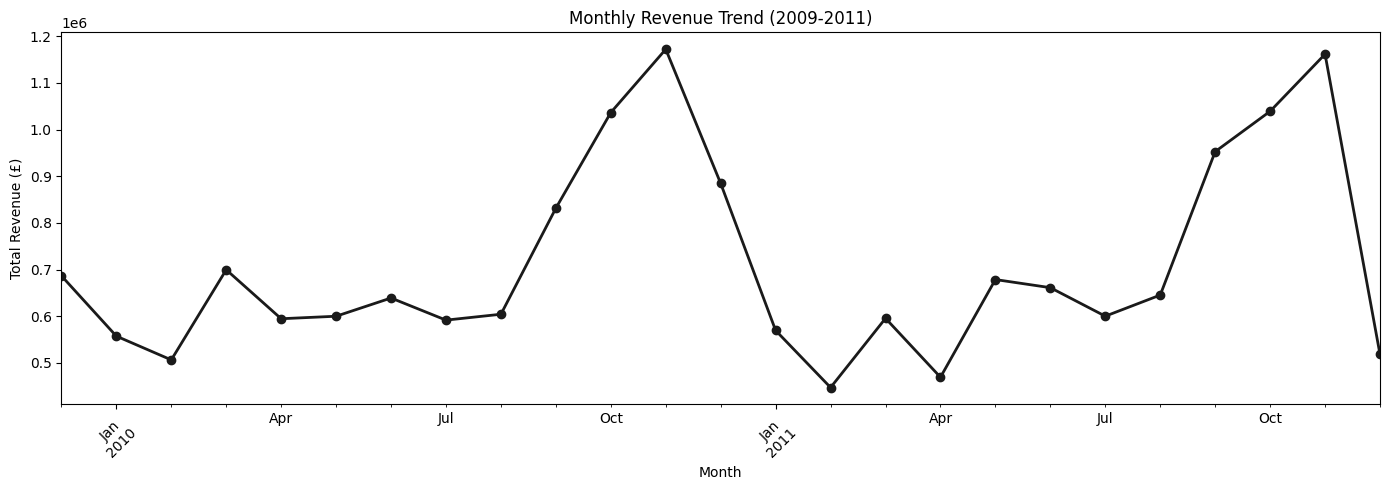

Peak revenue month: 2010-11 — £1,172,336.04
Lowest revenue month: 2011-02 — £447,137.35
Saved: fig2_monthly_revenue_trend.png


In [ ]:
# Monthly Revenue Trend (Seasonal Analysis)

df_clean['YearMonth'] = df_clean['InvoiceDate'].dt.to_period('M')
monthly_revenue = df_clean.groupby('YearMonth')['TotalPrice'].sum()

plt.figure(figsize=(14, 5))
monthly_revenue.plot(kind='line', marker='o', color='#1a1a1a', linewidth=2)
plt.title('Monthly Revenue Trend (2009-2011)')
plt.xlabel('Month')
plt.ylabel('Total Revenue (£)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('fig2_monthly_revenue_trend.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Peak revenue month: {monthly_revenue.idxmax()} — £{monthly_revenue.max():,.2f}')
print(f'Lowest revenue month: {monthly_revenue.idxmin()} — £{monthly_revenue.min():,.2f}')
print('Saved: fig2_monthly_revenue_trend.png')

Reference date: 2011-12-10

=== RFM TABLE (first 5 rows) ===
   Customer ID  Recency  Frequency  Monetary
0      12346.0      326         12  77556.46
1      12347.0        2          8   5633.32
2      12348.0       75          5   2019.40
3      12349.0       19          4   4428.69
4      12350.0      310          1    334.40

=== RFM DESCRIPTIVE STATISTICS ===
       Recency  Frequency   Monetary
count  5878.00    5878.00    5878.00
mean    201.33       6.29    3018.62
std     209.34      13.01   14737.73
min       1.00       1.00       2.95
25%      26.00       1.00     348.76
50%      96.00       3.00     898.92
75%     380.00       7.00    2307.09
max     739.00     398.00  608821.65


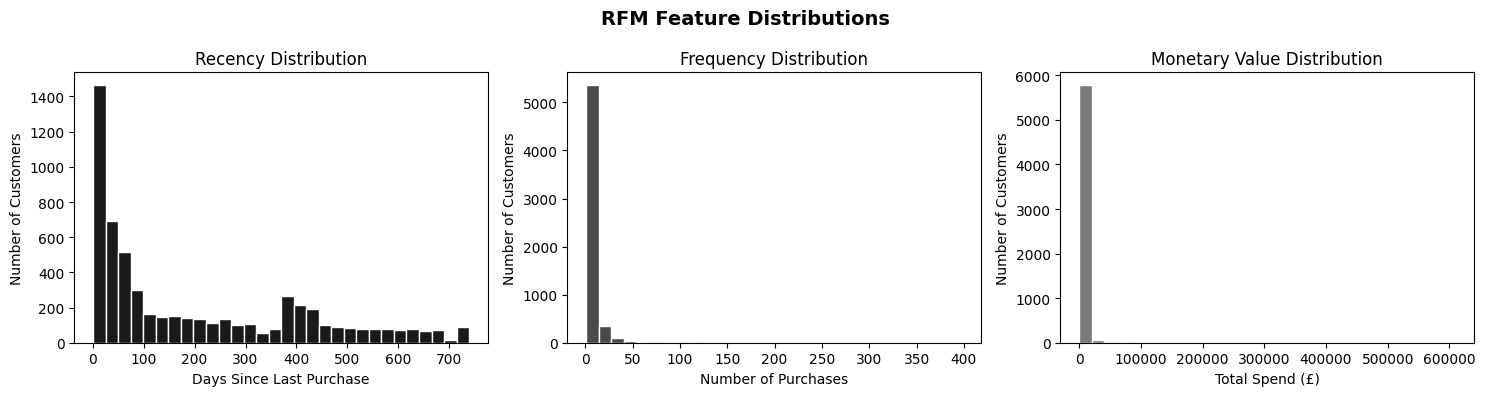

Saved: fig3_rfm_distributions.png


In [7]:
# RFM Calculation

reference_date = df_clean['InvoiceDate'].max() + pd.Timedelta(days=1)
print(f'Reference date: {reference_date.date()}')

rfm = df_clean.groupby('Customer ID').agg(
    Recency   = ('InvoiceDate', lambda x: (reference_date - x.max()).days),
    Frequency = ('Invoice', 'nunique'),
    Monetary  = ('TotalPrice', 'sum')
).reset_index()

print('\n=== RFM TABLE (first 5 rows) ===')
print(rfm.head())

print('\n=== RFM DESCRIPTIVE STATISTICS ===')
print(rfm[['Recency', 'Frequency', 'Monetary']].describe().round(2))

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(rfm['Recency'], bins=30, color='#1a1a1a', edgecolor='white')
axes[0].set_title('Recency Distribution')
axes[0].set_xlabel('Days Since Last Purchase')
axes[0].set_ylabel('Number of Customers')

axes[1].hist(rfm['Frequency'], bins=30, color='#4a4a4a', edgecolor='white')
axes[1].set_title('Frequency Distribution')
axes[1].set_xlabel('Number of Purchases')
axes[1].set_ylabel('Number of Customers')

axes[2].hist(rfm['Monetary'], bins=30, color='#7a7a7a', edgecolor='white')
axes[2].set_title('Monetary Value Distribution')
axes[2].set_xlabel('Total Spend (£)')
axes[2].set_ylabel('Number of Customers')

plt.suptitle('RFM Feature Distributions', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('fig3_rfm_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fig3_rfm_distributions.png')

=== CORRELATION MATRIX ===
           Recency  Frequency  Monetary
Recency      1.000     -0.257    -0.125
Frequency   -0.257      1.000     0.630
Monetary    -0.125      0.630     1.000


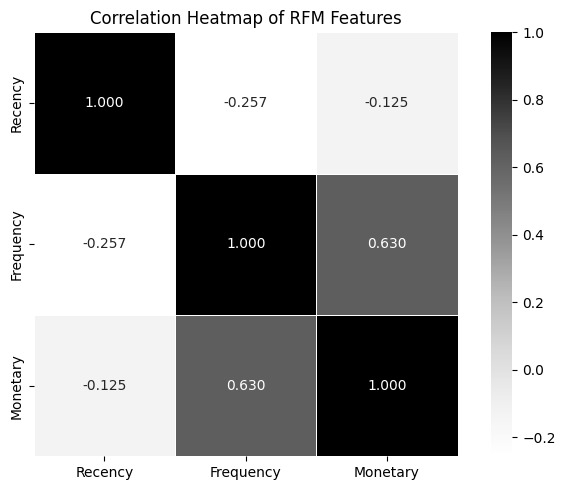


Frequency vs Monetary: 0.630
Recency vs Monetary:   -0.125
Recency vs Frequency:  -0.257
Saved: fig4_correlation_heatmap.png


In [8]:
# Correlation Heatmap

corr_matrix = rfm[['Recency', 'Frequency', 'Monetary']].corr()

print('=== CORRELATION MATRIX ===')
print(corr_matrix.round(3))

plt.figure(figsize=(7, 5))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.3f',
    cmap='Greys',
    linewidths=0.5,
    square=True
)
plt.title('Correlation Heatmap of RFM Features')
plt.tight_layout()
plt.savefig('fig4_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\nFrequency vs Monetary: {corr_matrix.loc["Frequency","Monetary"]:.3f}')
print(f'Recency vs Monetary:   {corr_matrix.loc["Recency","Monetary"]:.3f}')
print(f'Recency vs Frequency:  {corr_matrix.loc["Recency","Frequency"]:.3f}')
print('Saved: fig4_correlation_heatmap.png')

Median monetary threshold: £898.91

CLV Segment Distribution:
  High CLV (1): 2,939 customers (50.0%)
  Low CLV  (0): 2,939 customers (50.0%)


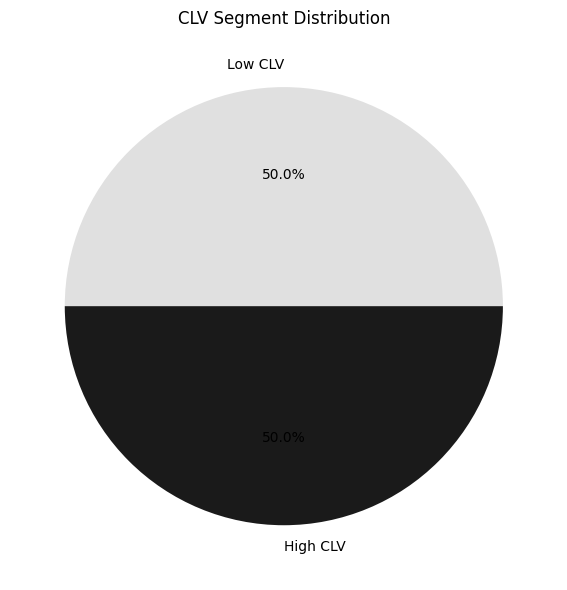


=== RFM AVERAGES BY CLV SEGMENT ===
             Recency  Frequency  Monetary
CLV_Segment                              
0             289.26       1.89    387.80
1             113.40      10.69   5649.43
Saved: fig5_clv_distribution.png


In [9]:
# Binary CLV Variable + Segment Distribution

median_monetary = rfm['Monetary'].median()
rfm['CLV_Segment'] = (rfm['Monetary'] > median_monetary).astype(int)

print(f'Median monetary threshold: £{median_monetary:.2f}')
print(f'\nCLV Segment Distribution:')
print(f'  High CLV (1): {rfm["CLV_Segment"].sum():,} customers ({rfm["CLV_Segment"].mean()*100:.1f}%)')
print(f'  Low CLV  (0): {(rfm["CLV_Segment"]==0).sum():,} customers ({(rfm["CLV_Segment"]==0).mean()*100:.1f}%)')

plt.figure(figsize=(6, 6))
rfm['CLV_Segment'].value_counts().plot.pie(
    autopct='%1.1f%%',
    colors=['#e0e0e0', '#1a1a1a'],
    labels=['Low CLV', 'High CLV']
)
plt.title('CLV Segment Distribution')
plt.ylabel('')
plt.tight_layout()
plt.savefig('fig5_clv_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n=== RFM AVERAGES BY CLV SEGMENT ===')
print(rfm.groupby('CLV_Segment')[['Recency','Frequency','Monetary']].mean().round(2))
print('Saved: fig5_clv_distribution.png')

  File "C:\Users\Admin\AppData\Roaming\Python\Python314\site-packages\joblib\externals\loky\backend\context.py", line 255, in _count_physical_cores
    raise ValueError(f"found {cpu_count_physical} physical cores < 1")


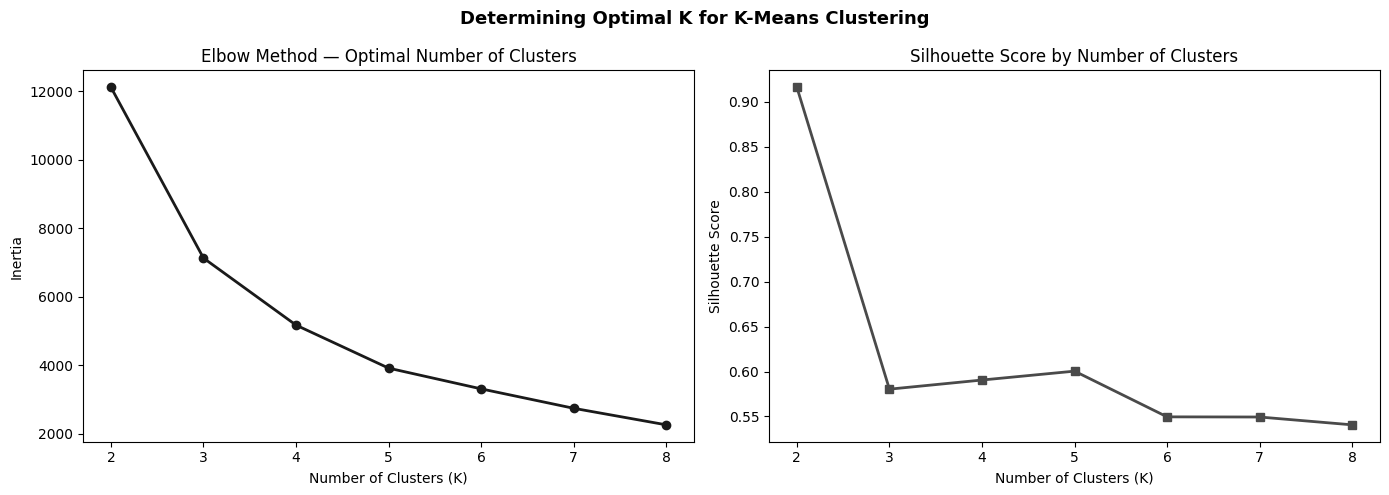

Best K based on silhouette score: 2
Best silhouette score: 0.916
Saved: fig6_elbow_silhouette.png


In [ ]:
# K-Means Clustering + PCA Visualisation

features = rfm[['Recency', 'Frequency', 'Monetary']].copy()
scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

# Elbow Method + Silhouette Scores
inertia = []
silhouette_scores = []
K_range = range(2, 9)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(scaled_features)
    inertia.append(km.inertia_)
    silhouette_scores.append(silhouette_score(scaled_features, km.labels_))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(K_range, inertia, marker='o', color='#1a1a1a', linewidth=2)
axes[0].set_title('Elbow Method — Optimal Number of Clusters')
axes[0].set_xlabel('Number of Clusters (K)')
axes[0].set_ylabel('Inertia')

axes[1].plot(K_range, silhouette_scores, marker='s', color='#4a4a4a', linewidth=2)
axes[1].set_title('Silhouette Score by Number of Clusters')
axes[1].set_xlabel('Number of Clusters (K)')
axes[1].set_ylabel('Silhouette Score')

plt.suptitle('Determining Optimal K for K-Means Clustering', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig6_elbow_silhouette.png', dpi=150, bbox_inches='tight')
plt.show()

best_k = K_range[silhouette_scores.index(max(silhouette_scores))]
print(f'Best K based on silhouette score: {best_k}')
print(f'Best silhouette score: {max(silhouette_scores):.3f}')
print('Saved: fig6_elbow_silhouette.png')

=== CUSTOMER SEGMENT PROFILES ===
         Recency  Frequency   Monetary  Customer Count
Cluster                                               
0         202.00       5.78    2366.66            5856
1          23.09     143.05  176557.66              22


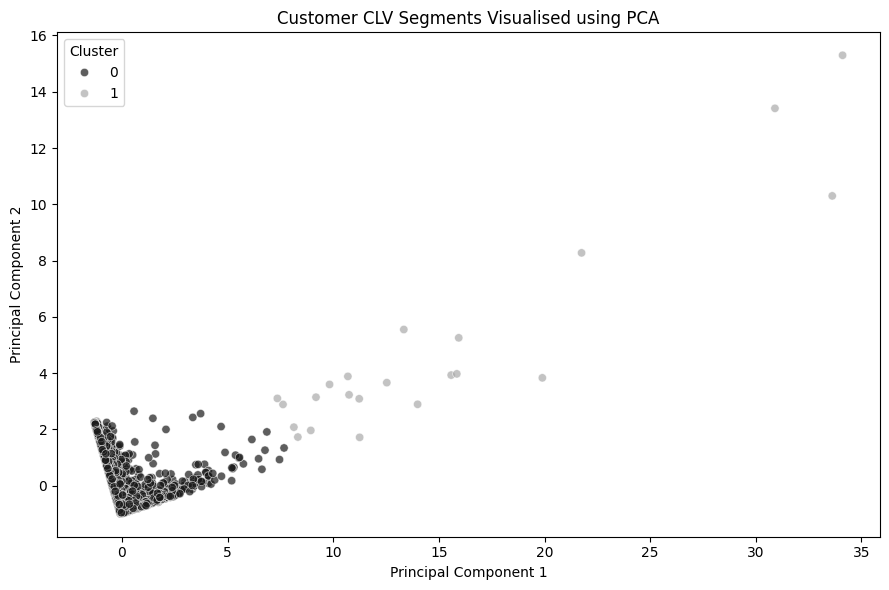

Saved: fig7_pca_clusters.png


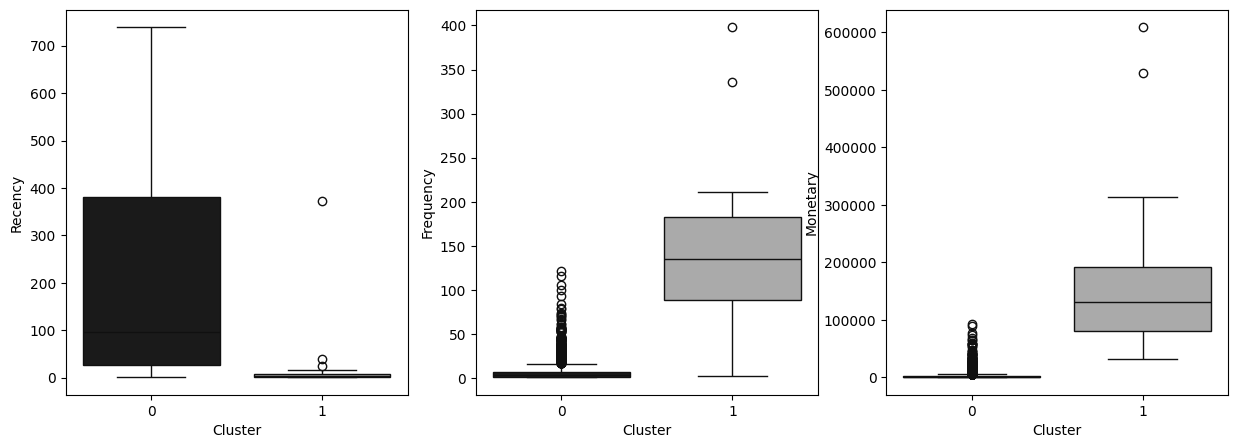

In [11]:
# Apply K-Means + PCA Visualisation + Boxplots

kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
rfm['Cluster'] = kmeans.fit_predict(scaled_features)

print('=== CUSTOMER SEGMENT PROFILES ===')
cluster_summary = rfm.groupby('Cluster')[['Recency','Frequency','Monetary']].mean().round(2)
cluster_summary['Customer Count'] = rfm.groupby('Cluster').size()
print(cluster_summary)

# PCA Visualisation
pca = PCA(n_components=2)
pca_components = pca.fit_transform(scaled_features)
pca_df = pd.DataFrame({
    'PCA1': pca_components[:, 0],
    'PCA2': pca_components[:, 1],
    'Cluster': rfm['Cluster'].astype(str)
})

plt.figure(figsize=(9, 6))
sns.scatterplot(
    x='PCA1', y='PCA2', hue='Cluster',
    palette=['#1a1a1a','#aaaaaa'], data=pca_df, alpha=0.7
)
plt.title('Customer CLV Segments Visualised using PCA')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Cluster')
plt.tight_layout()
plt.savefig('fig7_pca_clusters.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fig7_pca_clusters.png')

# Boxplots
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, col in zip(axes, ['Recency', 'Frequency', 'Monetary']):
    sns.boxplot(x='Cluster', y=col, data=rfm, ax=ax, palette=['#1a1a1a','#aaaaaa'])

In [13]:
# Logistic Regression

from sklearn.utils import resample

X = rfm[['Recency', 'Frequency', 'Monetary']]
y = rfm['CLV_Segment']

# Balance dataset
rfm_majority = rfm[rfm['CLV_Segment'] == 0]
rfm_minority = rfm[rfm['CLV_Segment'] == 1]

rfm_minority_upsampled = resample(
    rfm_minority,
    replace=True,
    n_samples=len(rfm_majority),
    random_state=42
)
rfm_balanced = pd.concat([rfm_majority, rfm_minority_upsampled])

X_bal = rfm_balanced[['Recency', 'Frequency', 'Monetary']]
y_bal = rfm_balanced['CLV_Segment']

scaler2 = StandardScaler()
X_scaled = scaler2.fit_transform(X_bal)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_bal, test_size=0.2, random_state=42
)

lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train, y_train)
lr_pred = lr_model.predict(X_test)
lr_proba = lr_model.predict_proba(X_test)[:, 1]

print('=== LOGISTIC REGRESSION RESULTS ===')
print(f'Accuracy: {accuracy_score(y_test, lr_pred)*100:.2f}%')
print(f'AUC-ROC:  {roc_auc_score(y_test, lr_proba):.4f}')
print('\nClassification Report:')
print(classification_report(y_test, lr_pred, target_names=['Low CLV', 'High CLV']))

coef_df = pd.DataFrame({
    'Feature': ['Recency', 'Frequency', 'Monetary'],
    'Coefficient': lr_model.coef_[0]
}).sort_values('Coefficient', ascending=False)
print('\nCoefficients (positive = increases High CLV chance):')
print(coef_df)

=== LOGISTIC REGRESSION RESULTS ===
Accuracy: 92.43%
AUC-ROC:  0.9824

Classification Report:
              precision    recall  f1-score   support

     Low CLV       0.89      0.97      0.93       603
    High CLV       0.96      0.88      0.92       573

    accuracy                           0.92      1176
   macro avg       0.93      0.92      0.92      1176
weighted avg       0.93      0.92      0.92      1176


Coefficients (positive = increases High CLV chance):
     Feature  Coefficient
2   Monetary    20.901662
1  Frequency     5.504376
0    Recency    -0.239654


=== RANDOM FOREST RESULTS ===
Accuracy: 100.00%
AUC-ROC:  1.0000

Classification Report:
              precision    recall  f1-score   support

     Low CLV       1.00      1.00      1.00       603
    High CLV       1.00      1.00      1.00       573

    accuracy                           1.00      1176
   macro avg       1.00      1.00      1.00      1176
weighted avg       1.00      1.00      1.00      1176


=== FEATURE IMPORTANCE ===
     Feature  Importance
2   Monetary    0.671618
1  Frequency    0.257854
0    Recency    0.070528


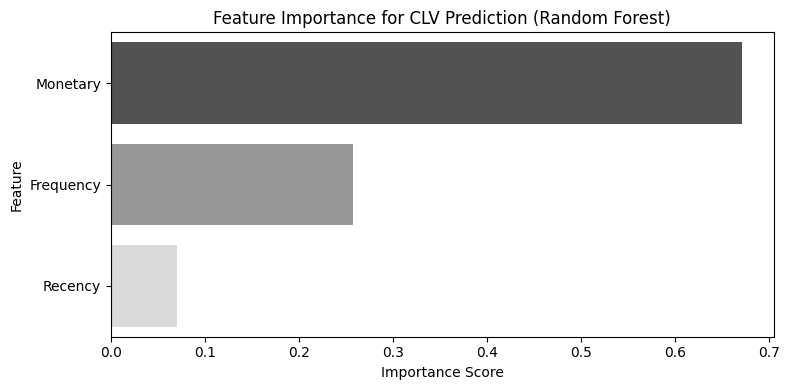

Saved: fig9_feature_importance.png


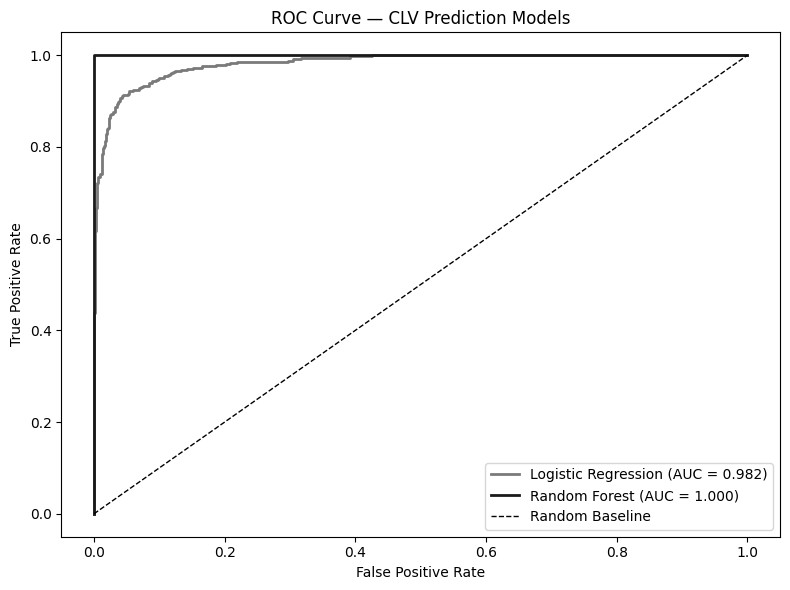

Saved: fig10_roc_curve.png


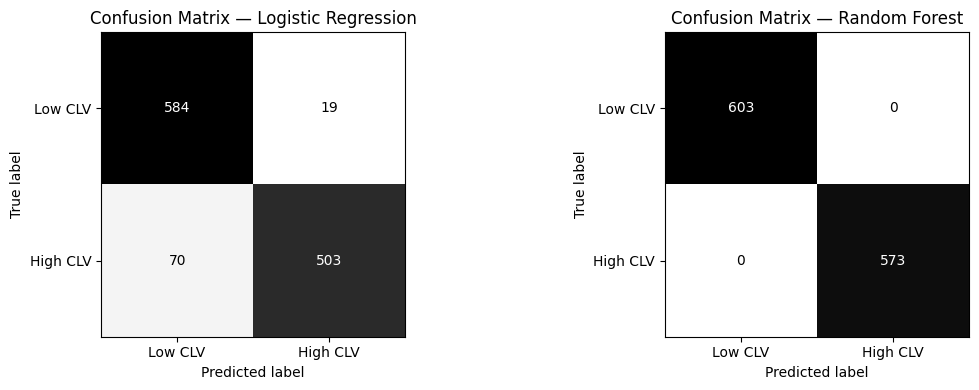

Saved: fig11_confusion_matrices.png

=== 5-FOLD CROSS VALIDATION ===
AUC-ROC scores: [1. 1. 1. 1. 1.]
Mean AUC-ROC:   1.0000 (+/- 0.0000)

=== FINAL MODEL COMPARISON ===
Model                     Accuracy        AUC-ROC
--------------------------------------------------
Logistic Regression       92.43%          0.9824
Random Forest             100.00%          1.0000


In [15]:
# Random Forest + Feature Importance + ROC + Confusion Matrix

rf_model = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=10)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)
rf_proba = rf_model.predict_proba(X_test)[:, 1]

print('=== RANDOM FOREST RESULTS ===')
print(f'Accuracy: {accuracy_score(y_test, rf_pred)*100:.2f}%')
print(f'AUC-ROC:  {roc_auc_score(y_test, rf_proba):.4f}')
print('\nClassification Report:')
print(classification_report(y_test, rf_pred, target_names=['Low CLV', 'High CLV']))

# Feature Importance
feat_importance = pd.DataFrame({
    'Feature': ['Recency', 'Frequency', 'Monetary'],
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

print('\n=== FEATURE IMPORTANCE ===')
print(feat_importance)

plt.figure(figsize=(8, 4))
sns.barplot(x='Importance', y='Feature', data=feat_importance, palette='Greys_r')
plt.title('Feature Importance for CLV Prediction (Random Forest)')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('fig9_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fig9_feature_importance.png')

# ROC Curves
fpr_lr, tpr_lr, _ = roc_curve(y_test, lr_proba)
fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_proba)

plt.figure(figsize=(8, 6))
plt.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC = {roc_auc_score(y_test, lr_proba):.3f})', color='#7a7a7a', linewidth=2)
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {roc_auc_score(y_test, rf_proba):.3f})', color='#1a1a1a', linewidth=2)
plt.plot([0,1],[0,1], 'k--', linewidth=1, label='Random Baseline')
plt.title('ROC Curve — CLV Prediction Models')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.tight_layout()
plt.savefig('fig10_roc_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fig10_roc_curve.png')

# Confusion Matrices
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, pred, title in zip(
    axes,
    [lr_pred, rf_pred],
    ['Logistic Regression', 'Random Forest']
):
    cm = confusion_matrix(y_test, pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=['Low CLV', 'High CLV'])
    disp.plot(ax=ax, colorbar=False, cmap='Greys')
    ax.set_title(f'Confusion Matrix — {title}')

plt.tight_layout()
plt.savefig('fig11_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fig11_confusion_matrices.png')

# Cross Validation
cv_scores = cross_val_score(rf_model, X_scaled, y_bal, cv=5, scoring='roc_auc')
print(f'\n=== 5-FOLD CROSS VALIDATION ===')
print(f'AUC-ROC scores: {cv_scores.round(4)}')
print(f'Mean AUC-ROC:   {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})')

print('\n=== FINAL MODEL COMPARISON ===')
print(f'{"Model":<25} {"Accuracy":<15} {"AUC-ROC"}')
print('-'*50)
print(f'{"Logistic Regression":<25} {accuracy_score(y_test, lr_pred)*100:.2f}%          {roc_auc_score(y_test, lr_proba):.4f}')
print(f'{"Random Forest":<25} {accuracy_score(y_test, rf_pred)*100:.2f}%          {roc_auc_score(y_test, rf_proba):.4f}')

=== CLV REVENUE CONCENTRATION ===
Total Revenue:          £17,743,429.18
High CLV Revenue:       £16,603,679.33 (93.6% of total)
Low CLV Revenue:        £1,139,749.85 (6.4% of total)

High CLV avg spend:     £5,649.43
Low CLV avg spend:      £387.80

High CLV avg frequency: 10.7 purchases
Low CLV avg frequency:  1.9 purchases


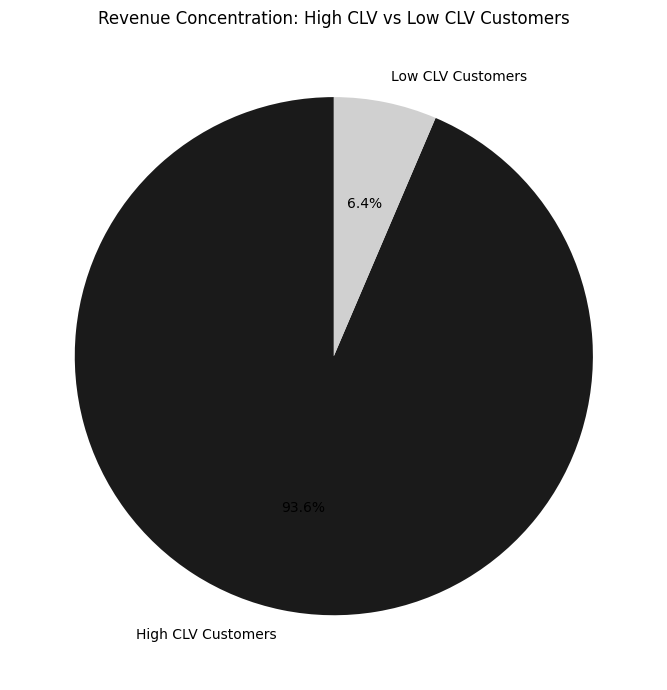

Saved: fig12_revenue_concentration.png

=== ALL ANALYSIS COMPLETE ===
Screenshots needed: fig1 through fig12
All figures also saved as PNG files in your mydataset folder


In [16]:
# CLV Revenue Concentration Analysis

total_revenue = rfm['Monetary'].sum()
high_clv_revenue = rfm[rfm['CLV_Segment']==1]['Monetary'].sum()
low_clv_revenue  = rfm[rfm['CLV_Segment']==0]['Monetary'].sum()

print('=== CLV REVENUE CONCENTRATION ===')
print(f'Total Revenue:          £{total_revenue:,.2f}')
print(f'High CLV Revenue:       £{high_clv_revenue:,.2f} ({high_clv_revenue/total_revenue*100:.1f}% of total)')
print(f'Low CLV Revenue:        £{low_clv_revenue:,.2f} ({low_clv_revenue/total_revenue*100:.1f}% of total)')
print(f'\nHigh CLV avg spend:     £{rfm[rfm["CLV_Segment"]==1]["Monetary"].mean():,.2f}')
print(f'Low CLV avg spend:      £{rfm[rfm["CLV_Segment"]==0]["Monetary"].mean():,.2f}')
print(f'\nHigh CLV avg frequency: {rfm[rfm["CLV_Segment"]==1]["Frequency"].mean():.1f} purchases')
print(f'Low CLV avg frequency:  {rfm[rfm["CLV_Segment"]==0]["Frequency"].mean():.1f} purchases')

plt.figure(figsize=(7, 7))
plt.pie(
    [high_clv_revenue, low_clv_revenue],
    labels=['High CLV Customers', 'Low CLV Customers'],
    autopct='%1.1f%%',
    colors=['#1a1a1a', '#d0d0d0'],
    startangle=90
)
plt.title('Revenue Concentration: High CLV vs Low CLV Customers')
plt.tight_layout()
plt.savefig('fig12_revenue_concentration.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fig12_revenue_concentration.png')

print('\n=== ALL ANALYSIS COMPLETE ===')
print('Screenshots needed: fig1 through fig12')
print('All figures also saved as PNG files in your mydataset folder')

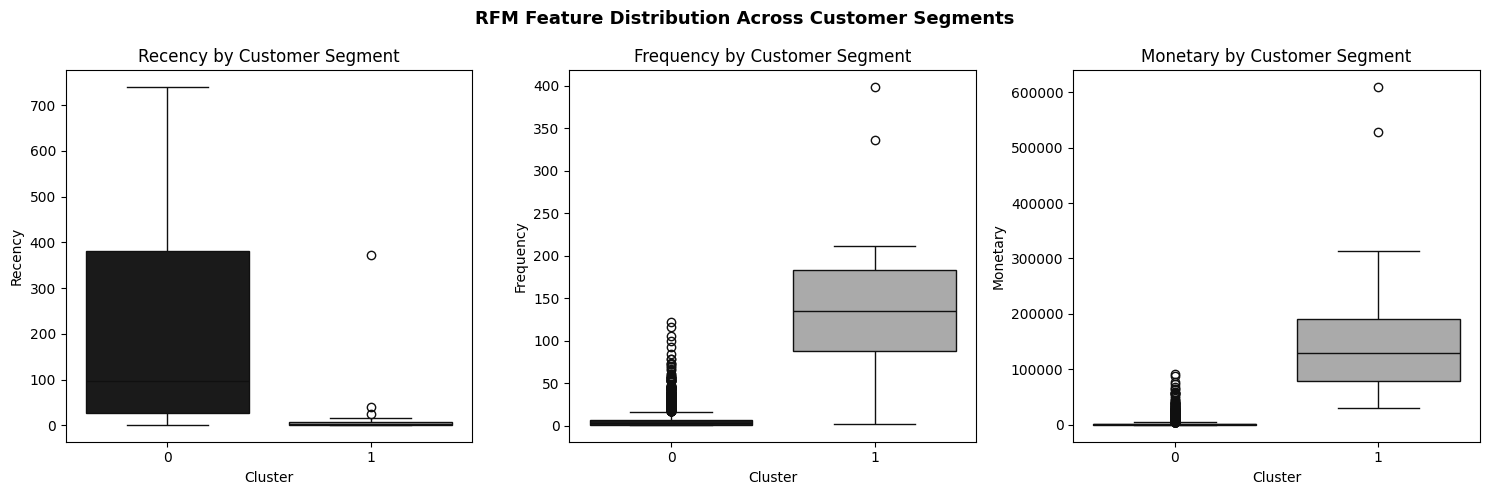

Saved: fig8_cluster_boxplots.png


In [17]:
# FIG 8 — Cluster Boxplots (Re-run)
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, col in zip(axes, ['Recency', 'Frequency', 'Monetary']):
    sns.boxplot(x='Cluster', y=col, data=rfm, ax=ax, palette=['#1a1a1a','#aaaaaa'])
    ax.set_title(f'{col} by Customer Segment')
plt.suptitle('RFM Feature Distribution Across Customer Segments', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig8_cluster_boxplots.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fig8_cluster_boxplots.png')